# Block Activation Analysis

## Research question

What low-dimensional structure is visible in the input, gated intermediate state, and output of one untouched SmolLM2 MLP block?

This notebook is a descriptive diagnostic. It does not replace the block and cannot establish that a particular compressed operator will preserve model quality. The default target is zero-based layer 11.

## Captured tensors and interpretation boundary

| Symbol | Capture point | Dimension for the configured model |
| --- | --- | ---: |
| x | Input to the complete MLP after the preceding normalization | d_model |
| z | Input to down_proj, after SwiGLU gating | d_ff |
| y | MLP branch output before residual addition | d_model |

PCA is used as a reconstruction oracle. It is not a deployable narrow SwiGLU because computing z still requires the original full-width gated projections. Measurements apply only to this model, layer, calibration distribution, and seed.

In [1]:
from dataclasses import asdict
from pathlib import Path
import json
import sys

def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from mlp_replacement.analysis import (
    coordinate_orders,
    covariance_eigendecomposition,
    evaluate_reconstruction,
    summarize_activation_spectrum,
)
from mlp_replacement.capture import collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.model import discover_mlp_blocks, get_mlp_block, load_model_and_tokenizer
from mlp_replacement.runlog import environment_record, json_value

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
TARGET_LAYER = 11
PCA_RANKS = (64, 128, 256, 512, 1024, 2048, 4096)
SEED = 21
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / f'activation-layer-{TARGET_LAYER}.json'
)

model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device=DEVICE,
    dtype='auto',
)
data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=1,
    num_test_batches=0,
    seed=SEED,
)
torch.manual_seed(SEED)

print({
    'target_layer': TARGET_LAYER,
    'device': DEVICE,
    'pca_ranks': PCA_RANKS,
    'output': str(OUTPUT_PATH),
})

{'target_layer': 11, 'device': 'cuda', 'pca_ranks': (64, 128, 256, 512, 1024, 2048, 4096), 'output': 'C:\\Users\\samue\\OneDrive - Univerzita Komenskeho v Bratislave\\Diplomová práca\\Diplomova Praca\\development\\data\\results\\notebook-block-study\\activation-layer-11.json'}


## Capture and sanity checks

Calibration activations define the covariance bases and coordinate orderings. A document-disjoint validation split is reserved for reconstruction evaluation. Raw activation tensors remain in memory and are not written to the result artifact.

In [3]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
loaders = build_data_loaders(tokenizer, data_config, include_recovery=False)
block = get_mlp_block(model, TARGET_LAYER)
down_path = f'{block.path}.down_proj'
down_projection = model.get_submodule(down_path)

capture_kwargs = {
    'device': device,
    'storage_device': 'cpu',
    'storage_dtype': torch.float32,
}
training_xy = collect_module_io(
    model,
    block.path,
    loaders.calibration,
    data_config.num_calibration_batches,
    **capture_kwargs,
)
training_zy = collect_module_io(
    model,
    down_path,
    loaders.calibration,
    data_config.num_calibration_batches,
    **capture_kwargs,
)
validation_xy = collect_module_io(
    model,
    block.path,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)
validation_zy = collect_module_io(
    model,
    down_path,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)

training_activations = {
    'x': training_xy.inputs,
    'z': training_zy.inputs,
    'y': training_xy.targets,
}
validation_activations = {
    'x': validation_xy.inputs,
    'z': validation_zy.inputs,
    'y': validation_xy.targets,
}

capture_df = pd.DataFrame([
    {
        'activation': name,
        'split': split,
        'tokens': values.shape[0],
        'dimension': values.shape[1],
    }
    for split, mapping in [
        ('calibration', training_activations),
        ('validation', validation_activations),
    ]
    for name, values in mapping.items()
])
capture_df

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


,activation,split,tokens,dimension
0,x,calibration,12288,2048
1,z,calibration,12288,8192
2,y,calibration,12288,2048
3,x,validation,6144,2048
4,z,validation,6144,8192
5,y,validation,6144,2048


In [4]:
def activation_summary(name, values):
    values = values.float()
    norms = values.norm(dim=-1)
    mean_energy = values.mean(dim=0).square().sum()
    second_moment = values.square().sum(dim=-1).mean()
    return {
        'activation': name,
        'tokens': values.shape[0],
        'dimension': values.shape[1],
        'mean': float(values.mean()),
        'std': float(values.std()),
        'mean_norm': float(norms.mean()),
        'p50_norm': float(norms.median()),
        'p95_norm': float(torch.quantile(norms, 0.95)),
        'mean_energy_fraction': float(mean_energy / second_moment),
    }

def binned_distribution(values, bins=100, max_samples=100_000):
    flat = values.flatten().float()
    sampled = flat[::max(1, flat.numel() // max_samples)]
    counts, edges = torch.histogram(sampled, bins=bins, density=True)
    return [
        {
            'left': float(edges[index]),
            'right': float(edges[index + 1]),
            'density': float(counts[index]),
        }
        for index in range(counts.numel())
    ]

def binned_norms(values, bins=80):
    norms = values.float().norm(dim=-1)
    counts, edges = torch.histogram(norms, bins=bins, density=True)
    return [
        {
            'left': float(edges[index]),
            'right': float(edges[index + 1]),
            'density': float(counts[index]),
        }
        for index in range(counts.numel())
    ]

descriptive_df = pd.DataFrame([
    activation_summary(name, values)
    for name, values in training_activations.items()
])
# Retained for activation-artifact compatibility; intentionally not plotted in
# this focused report.
histogram_data = {
    name: {
        'values': binned_distribution(values),
        'norms': binned_norms(values),
    }
    for name, values in training_activations.items()
}
descriptive_df

,activation,tokens,dimension,mean,std,mean_norm,p50_norm,p95_norm,mean_energy_fraction
0,x,12288,2048,-0.000395,0.091182,4.104434,4.096056,4.616749,0.179218
1,z,12288,8192,0.000055,0.118640,10.573307,10.379230,13.601201,0.036548
2,y,12288,2048,0.001717,1.265742,56.255814,54.800049,74.186394,0.033518


## Covariance spectra

The participation-ratio effective rank, stable rank, and explained-variance thresholds summarize different aspects of the centered covariance spectrum. None is treated as the correct replacement width. The z eigendecomposition is the expensive step intended for the remote GPU.

In [5]:
decompositions = {}
spectra = {}
for name, values in training_activations.items():
    decomposition = covariance_eigendecomposition(
        values,
        device=DEVICE,
        with_eigenvectors=(name == 'z'),
    )
    decompositions[name] = decomposition
    spectra[name] = summarize_activation_spectrum(
        values,
        decomposition,
    )

spectrum_df = pd.DataFrame([
    {
        'activation': name,
        **summary.to_dict(include_eigenvalues=False),
    }
    for name, summary in spectra.items()
])
spectrum_df

,activation,num_tokens,dimension,effective_rank,normalized_effective_rank,stable_rank,normalized_stable_rank,k90,k95,k99,mean_energy_fraction
0,x,12288,2048,302.676218,0.147791,31.341790,0.015304,1160,1465,1864,0.179218
1,z,12288,8192,1081.457077,0.132014,104.319589,0.012734,3239,4338,6290,0.036548
2,y,12288,2048,124.518428,0.060800,12.175369,0.005945,1075,1361,1785,0.033518


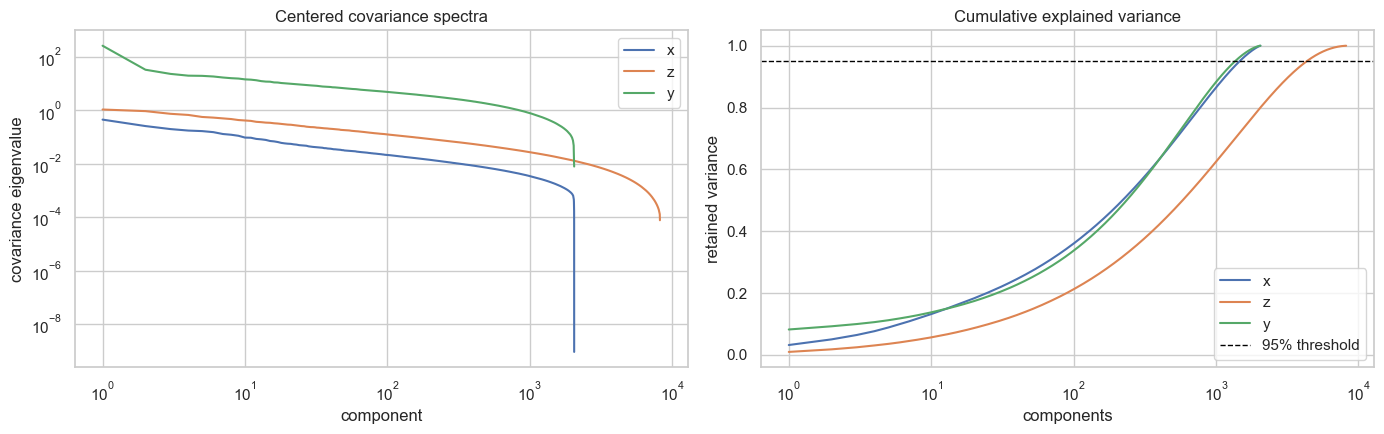

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, summary in spectra.items():
    eigenvalues = summary.eigenvalues
    components = torch.arange(1, eigenvalues.numel() + 1)
    axes[0].plot(
        components,
        eigenvalues.clamp_min(1e-12),
        label=name,
    )
    axes[1].plot(
        components,
        eigenvalues.cumsum(0) / eigenvalues.sum(),
        label=name,
    )

axes[0].set(
    xscale='log',
    yscale='log',
    xlabel='component',
    ylabel='covariance eigenvalue',
    title='Centered covariance spectra',
)
axes[1].set(
    xscale='log',
    xlabel='components',
    ylabel='retained variance',
    title='Cumulative explained variance',
)
axes[1].axhline(
    0.95,
    color='black',
    linestyle='--',
    linewidth=1,
    label='95% threshold',
)
for axis in axes:
    axis.legend()
plt.tight_layout()

## Held-out reconstruction

PCA reconstruction is compared with two coordinate-retention controls using the same retained dimensions. Error is measured both in z and after applying the original down projection. A low z reconstruction error alone does not imply low complete-model degradation.

In [7]:
z_decomposition = decompositions['z']
orders = coordinate_orders(
    training_activations['z'],
    seed=SEED,
)
down_weight = down_projection.weight.detach().cpu()
down_bias = (
    down_projection.bias.detach().cpu()
    if down_projection.bias is not None
    else None
)

reconstruction_results = []
reconstruction_results.extend(
    evaluate_reconstruction(
        validation_activations['z'],
        z_decomposition.mean,
        PCA_RANKS,
        method='pca',
        basis=z_decomposition.eigenvectors,
        output_weight=down_weight,
        output_bias=down_bias,
        device=DEVICE,
    )
)
for method, order in orders.items():
    reconstruction_results.extend(
        evaluate_reconstruction(
            validation_activations['z'],
            z_decomposition.mean,
            PCA_RANKS,
            method=method,
            coordinate_order=order,
            output_weight=down_weight,
            output_bias=down_bias,
            device=DEVICE,
        )
    )

reconstruction_df = pd.DataFrame([
    asdict(result)
    for result in reconstruction_results
])
reconstruction_df

,method,rank,activation_relative_mse,output_relative_mse
0,pca,64,0.858529,0.808186
1,pca,128,0.817213,0.770768
2,pca,256,0.760297,0.720645
3,pca,512,0.684462,0.649069
4,pca,1024,0.583727,0.548580
5,pca,2048,0.448677,0.411817
6,pca,4096,0.262951,0.232280
7,random_coordinates,64,0.958413,0.960802
8,random_coordinates,128,0.949549,0.951961
9,random_coordinates,256,0.935567,0.935464


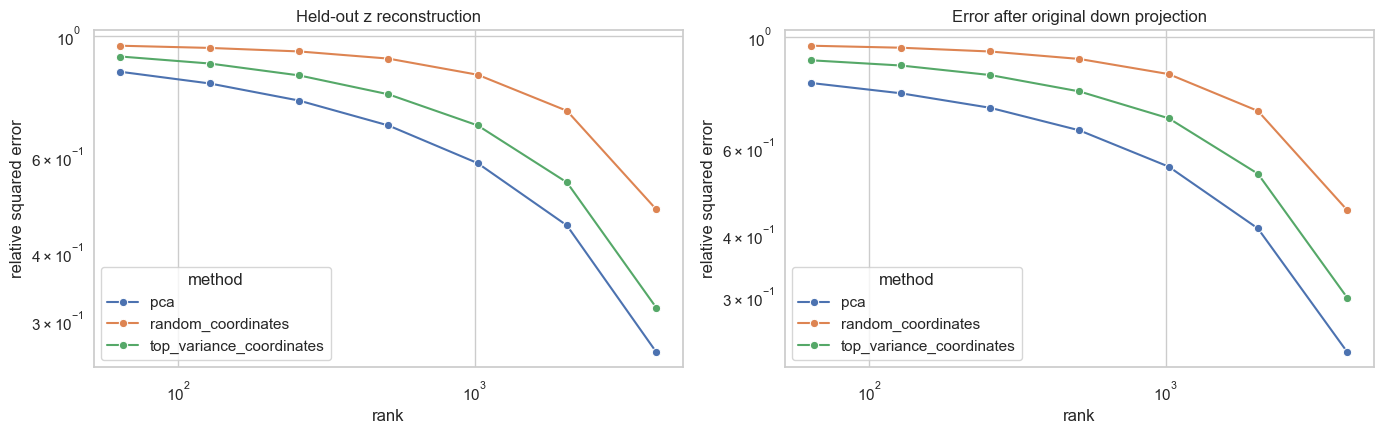

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=reconstruction_df,
    x='rank',
    y='activation_relative_mse',
    hue='method',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=reconstruction_df,
    x='rank',
    y='output_relative_mse',
    hue='method',
    marker='o',
    ax=axes[1],
)
axes[0].set(
    xscale='log',
    yscale='log',
    title='Held-out z reconstruction',
    ylabel='relative squared error',
)
axes[1].set(
    xscale='log',
    yscale='log',
    title='Error after original down projection',
    ylabel='relative squared error',
)
plt.tight_layout()

In [9]:
artifact = {
    'schema_version': 1,
    'status': 'exploratory',
    'model': {
        'id': model_config.model_id,
        'resolved_revision': getattr(model.config, '_commit_hash', None),
        'target_layer': TARGET_LAYER,
        'mlp_path': block.path,
        'requested_config': asdict(model_config),
    },
    'data': {
        'sequence_length': data_config.sequence_length,
        'calibration_batches': data_config.num_calibration_batches,
        'validation_batches': data_config.num_operator_validation_batches,
        'seed': SEED,
        'requested_config': asdict(data_config),
    },
    'pca_ranks': list(PCA_RANKS),
    'environment': environment_record(),
    'descriptive': descriptive_df.to_dict(orient='records'),
    'histograms': histogram_data,
    'spectra': {
        name: summary.to_dict()
        for name, summary in spectra.items()
    },
    'reconstruction': reconstruction_df.to_dict(orient='records'),
}
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(
    json.dumps(json_value(artifact), indent=2, allow_nan=False),
    encoding='utf-8',
)
print(f'Saved activation summary to {OUTPUT_PATH}')

Saved activation summary to C:\Users\samue\OneDrive - Univerzita Komenskeho v Bratislave\Diplomová práca\Diplomova Praca\development\data\results\notebook-block-study\activation-layer-11.json


### Activation distribution

- compare k-blocks activation distributions (e.g. kernel plot or histogram) -> outlier analysis
- expected result: deeper layers have high variance

In [10]:
DISTRIBUTION_SAMPLES_PER_LAYER = 50_000
DISTRIBUTION_QUANTILE = 0.995
DISTRIBUTION_BINS = 160

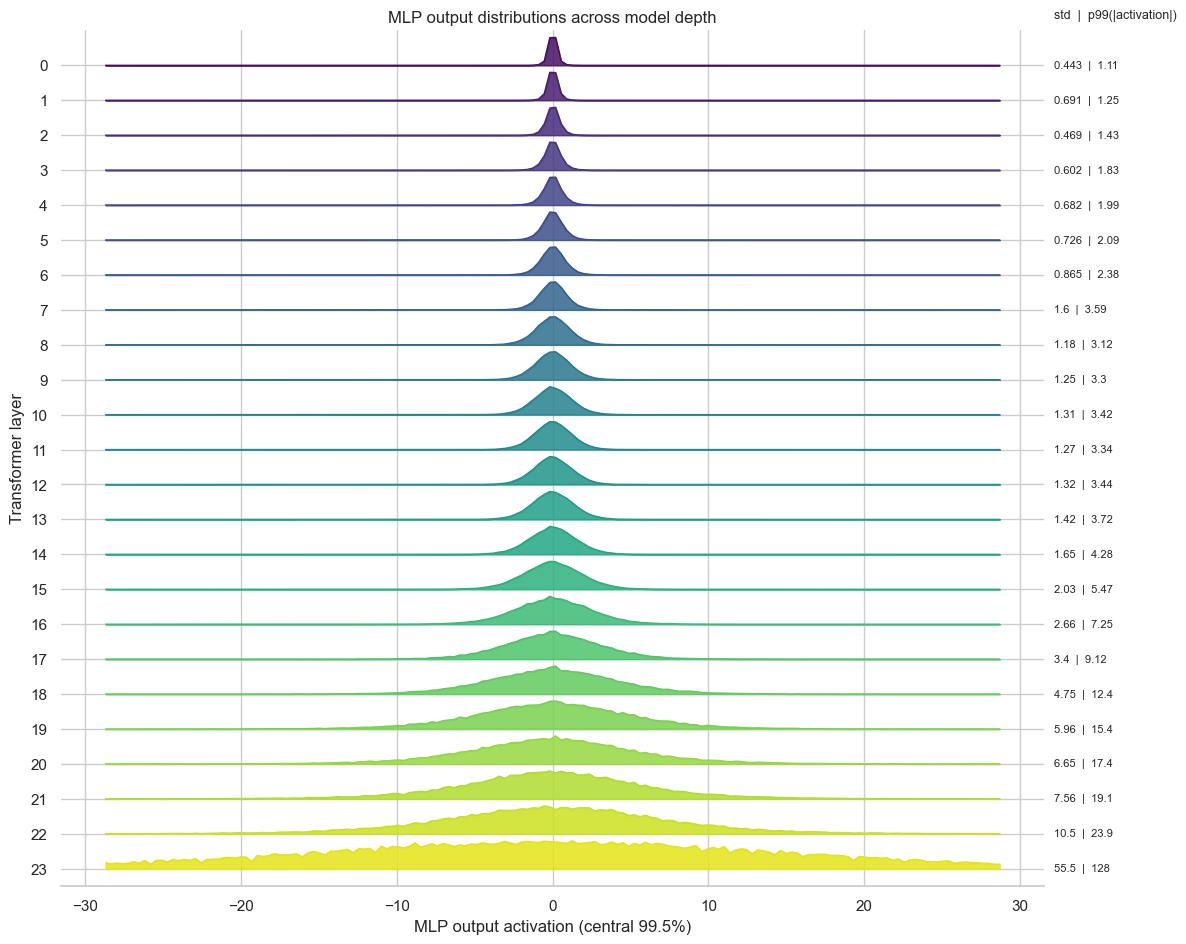

In [11]:
mlp_blocks = discover_mlp_blocks(model)
distribution_batches = data_config.num_calibration_batches
samples_per_batch = (
    DISTRIBUTION_SAMPLES_PER_LAYER + distribution_batches - 1
) // distribution_batches
output_chunks = {block_ref.index: [] for block_ref in mlp_blocks}
handles = []

for block_ref in mlp_blocks:
    def capture_output(_module, _args, output, layer_index=block_ref.index):
        values = output.detach().reshape(-1).float()
        indices = torch.linspace(
            0, values.numel() - 1, samples_per_batch, device=values.device
        ).long()
        output_chunks[layer_index].append(values[indices].cpu())

    handles.append(block_ref.module.register_forward_hook(capture_output))

was_training = model.training
model.eval()
try:
    with torch.no_grad():
        for batch_index, batch in enumerate(loaders.calibration):
            if batch_index >= distribution_batches:
                break
            device_batch = {
                key: value.to(device) if isinstance(value, torch.Tensor) else value
                for key, value in batch.items()
            }
            model(**device_batch)
finally:
    for handle in handles:
        handle.remove()
    model.train(was_training)

layer_output_samples = {
    layer_index: torch.cat(chunks)[:DISTRIBUTION_SAMPLES_PER_LAYER]
    for layer_index, chunks in output_chunks.items()
}
all_output_samples = torch.cat(list(layer_output_samples.values()))
display_limit = float(torch.quantile(all_output_samples.abs(), DISTRIBUTION_QUANTILE))
bin_edges = torch.linspace(-display_limit, display_limit, DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
layer_indices = [block_ref.index for block_ref in mlp_blocks]
palette = sns.color_palette('viridis', n_colors=len(layer_indices))

fig, ax = plt.subplots(figsize=(14, max(8, len(layer_indices) * 0.4)))
for color, layer_index in zip(palette, layer_indices):
    samples = layer_output_samples[layer_index]
    visible_samples = samples[samples.abs() <= display_limit]
    density = torch.histogram(visible_samples, bins=bin_edges, density=True).hist
    ridge_height = density / density.max().clamp_min(1e-12) * 0.8
    ax.axhline(layer_index, color='0.85', linewidth=0.6, zorder=0)
    ax.fill_between(
        bin_centers.numpy(), layer_index, layer_index - ridge_height.numpy(),
        color=color, alpha=0.85,
    )
    ax.plot(
        bin_centers.numpy(), layer_index - ridge_height.numpy(),
        color=color, linewidth=1.0,
    )
    standard_deviation = float(samples.std())
    p99_magnitude = float(torch.quantile(samples.abs(), 0.99))
    ax.text(
        1.01,
        layer_index,
        f'{standard_deviation:.3g}  |  {p99_magnitude:.3g}',
        transform=ax.get_yaxis_transform(),
        va='center',
        fontsize=8,
        clip_on=False,
    )

ax.set(
    xlabel=f'MLP output activation (central {DISTRIBUTION_QUANTILE:.1%})',
    ylabel='Transformer layer',
    title='MLP output distributions across model depth',
)
ax.set_yticks(layer_indices)
ax.set_ylim(max(layer_indices) + 0.5, min(layer_indices) - 1.0)
ax.text(
    1.01, 1.01, 'std  |  p99(|activation|)',
    transform=ax.transAxes, ha='left', va='bottom', fontsize=9,
)
sns.despine(ax=ax, left=True)
plt.tight_layout(rect=(0, 0, 0.86, 1))